In [6]:
# ==============================================================
# Empirical Analysis: Super-Hedging with Transaction Costs
# ==============================================================
# This notebook analyzes super-hedging results for different transaction cost rates (kappa).
# It loads simulation results, visualizes key metrics, and exports summary tables for publication.
#
# Author: [Your Name]
# Date: [Today's Date]

# -----------------------------
# 1. Import Required Libraries
# -----------------------------
import os
import importlib
import numpy as np
import pandas as pd
import def_plots as dp
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from sklearn.metrics import r2_score
importlib.reload(dp)

<module 'def_plots' from '/Users/omrani/Desktop/A2Amal-29042026/EmpiricalResults/def_plots.py'>

In [7]:
# -----------------------------
# 2. Load Simulation Results and Set Up Labels
# -----------------------------
# Load results for each kappa value and concatenate into a single DataFrame
d0    = dp.load_and_metrics("results_kappa_0.csv",      r"$\kappa=0$")
d0005 = dp.load_and_metrics("results_kappa_0.0005.csv", r"$\kappa=5\times10^{-4}$")
d001  = dp.load_and_metrics("results_kappa_0.001.csv",  r"$\kappa=10^{-3}$")
d005 = dp.load_and_metrics("results_kappa_0.005.csv",  r"$\kappa=5\times10^{-3}$")
d009 = dp.load_and_metrics("results_kappa_0.009.csv",  r"$\kappa=9\times10^{-3}$")
#d01   = dp.load_and_metrics("results_kappa_0.01.csv",   r"$\kappa=10^{-2}$")

allm = pd.concat([d0, d0005, d001, d005, d009], ignore_index=True)
# Define the exact labels for each kappa value (used for plotting and grouping)
label_0 = r"$\kappa=0$"
label_0005 = r"$\kappa=5\times10^{-4}$"
label_001 = r"$\kappa=10^{-3}$"
label_005 = r"$\kappa=5\times10^{-3}$"
label_009 = r"$\kappa=9\times10^{-3}$"
#label_01 = r"$\kappa=10^{-2}$"


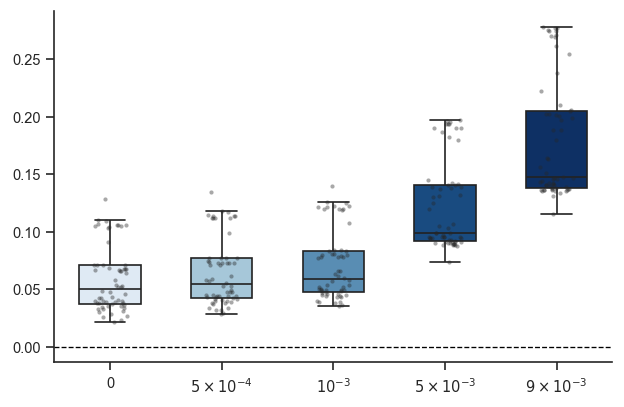

In [8]:
# -----------------------------
# 3. Visualize Relative Super-Hedging Error (RSE)
# -----------------------------
# Boxplot of RSE for each kappa value
# yb, yt = dp.auto_broken_limits(allm, ycol="RSE", main_q=0.98, outlier_q=0.995, pad=0.005)
dp.plot_rse(
    allm,
    ycol="RSE",
    savepath="Fig_RSE.pdf"
)

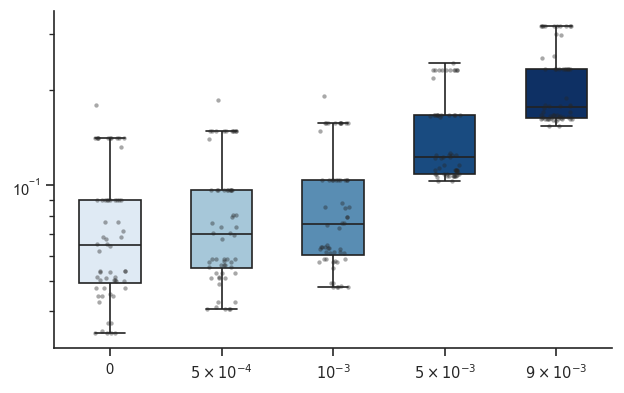

In [9]:
# -----------------------------
# 4. Visualize Normalized Price (Pj) on Log Scale
# -----------------------------
# Boxplot of normalized price (Pj) for each kappa value (log scale)
dp.plot_pj_logscale(
    allm,
    ycol="Pj",
    savepath="Fig_Pj_logscale.pdf"
)

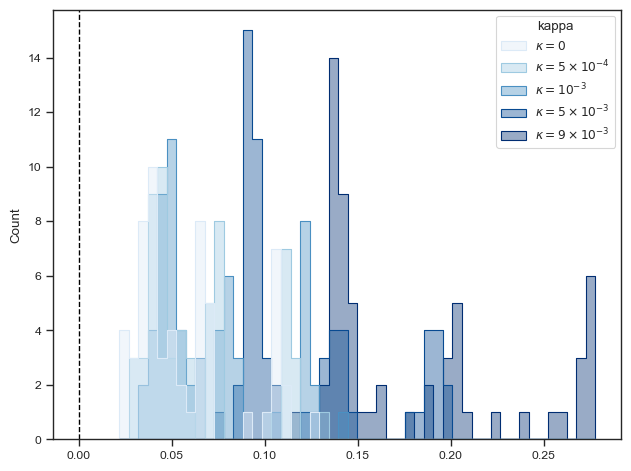

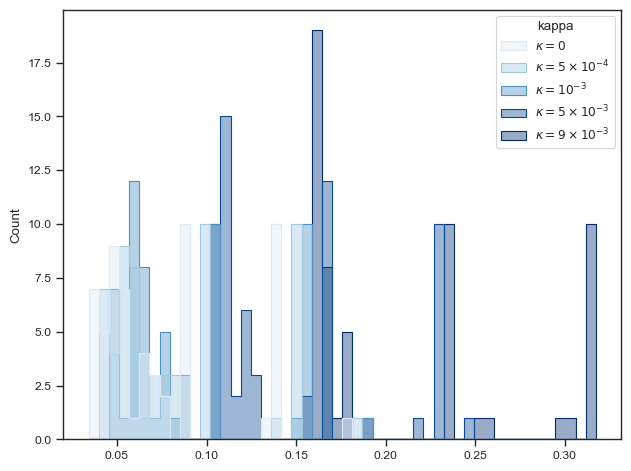

In [11]:
# -----------------------------
# 5. Histograms: RSE and Normalized Price by Kappa
# -----------------------------
# Plot histograms of RSE and Pj for each kappa value (color-coded)
order = [r"$\kappa=0$", r"$\kappa=5\times10^{-4}$", r"$\kappa=10^{-3}$", r"$\kappa=5\times10^{-3}$", r"$\kappa=9\times10^{-3}$"]
palette = {
    order[0]: "#DCEAF7",
    order[1]: "#9ECAE1",
    order[2]: "#4A90C2",
    order[3]: "#084A91",
    order[4]: "#002D72"
}

plot_data = allm.copy()
plot_data["kappa"] = pd.Categorical(plot_data["kappa"], categories=order, ordered=True)

rse_data = plot_data[np.isfinite(plot_data["RSE"])]
pj_data  = plot_data[np.isfinite(plot_data["Pj"])]

# Histogram of relative super-hedging error (RSE)
fig, ax = plt.subplots()
sns.histplot(
    data=rse_data, x="RSE", hue="kappa", hue_order=order,
    palette=palette, common_norm=False, 
    alpha=0.4, element="step", bins=50, ax=ax
)
ax.axvline(0, color="black", ls="--", lw=1.0)
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("fig_rse_hist.pdf", bbox_inches="tight")
plt.savefig("fig_rse_hist.png", bbox_inches="tight")
plt.show()

# Histogram of normalized price (Pj)
fig, ax = plt.subplots()
sns.histplot(
    data=pj_data, x="Pj", hue="kappa", hue_order=order,
    palette=palette, common_norm=False, 
    alpha=0.4, element="step", bins=50, ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("fig_pj_hist.pdf", bbox_inches="tight")
plt.savefig("fig_pj_hist.png", bbox_inches="tight")
plt.show()

In [12]:
# -----------------------------
# 6. Summary Table: Normalized Prices by Kappa
# -----------------------------
# Generate and display summary statistics for normalized prices (Pj) by kappa
stat_table_NP= allm.groupby('kappa')['Pj'].describe()

# Define the exact order from smallest to highest kappa
kappa_order = [
    r"$\kappa=0$", 
    r"$\kappa=5\times10^{-4}$", 
    r"$\kappa=10^{-3}$", 
    r"$\kappa=5\times10^{-3}$",
    r"$\kappa=9\times10^{-3}$"
]
# Force the table to use this exact row order
stat_table_NP = stat_table_NP.reindex(kappa_order)

# Display the nicely formatted table
display(stat_table_NP.round(4))

,count,mean,std,min,25%,50%,75%,max
kappa,,,,,,,,
$\kappa=0$,60.0,0.0764,0.0380,0.0342,0.0492,0.0647,0.0900,0.1797
$\kappa=5\times10^{-4}$,60.0,0.0828,0.0388,0.0408,0.0548,0.0700,0.0969,0.1857
$\kappa=10^{-3}$,60.0,0.0894,0.0396,0.0478,0.0605,0.0755,0.1040,0.1919
$\kappa=5\times10^{-3}$,60.0,0.1472,0.0477,0.1029,0.1087,0.1226,0.1662,0.2438
$\kappa=9\times10^{-3}$,60.0,0.2100,0.0598,0.1541,0.1625,0.1765,0.2332,0.3172


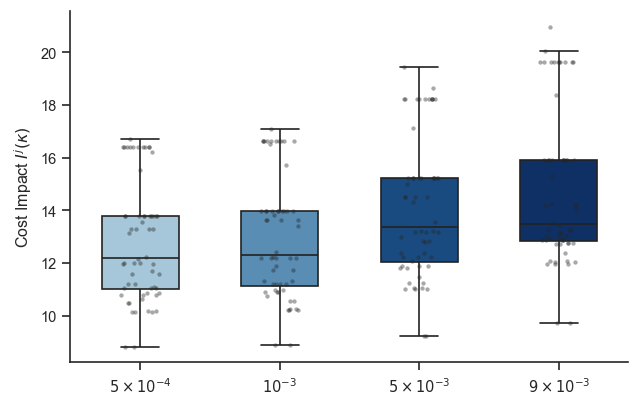

In [13]:
# -----------------------------
# 7. Compute and Visualize Cost Impact (I)
# -----------------------------
# Compute the cost impact (I) for each row and plot the result
df_impact = dp.compute_I(allm, pj_col="Pj", kappa_col="kappa", id_col="i")

# Visualize cost impact
dp.plot_impact_cost(df_impact, ycol="I", savepath="Fig_Impact_Cost.pdf")

In [14]:
# -----------------------------
# 8. Summary Table: Cost Impact by Kappa
# -----------------------------
# Generate and display summary statistics for cost impact (I) by kappa
stat_table_CI = df_impact.groupby('kappa')['I'].describe()

# Define the exact order from smallest to highest kappa
kappa_order_CI = [ 
    r"$\kappa=5\times10^{-4}$", 
    r"$\kappa=10^{-3}$", 
    r"$\kappa=5\times10^{-3}$",
    r"$\kappa=9\times10^{-3}$"
]
# Force the table to use this exact row order
stat_table_CI = stat_table_CI.reindex(kappa_order_CI)

# Display the nicely formatted table
display(stat_table_CI.round(4))

,count,mean,std,min,25%,50%,75%,max
kappa,,,,,,,,
$\kappa=5\times10^{-4}$,60.0,12.8466,2.2711,8.8347,11.0179,12.1911,13.8035,16.7241
$\kappa=10^{-3}$,60.0,13.0257,2.3241,8.8871,11.1461,12.3263,13.9889,17.1049
$\kappa=5\times10^{-3}$,60.0,14.1481,2.6591,9.2385,12.0402,13.3838,15.2378,19.4457
$\kappa=9\times10^{-3}$,60.0,14.8382,2.9299,9.7285,12.8580,13.4861,15.9097,20.9534


In [15]:
# -----------------------------
# 9. Summary Table: Relative Super-Hedging Error (RSE) by Kappa
# -----------------------------
# Generate and display summary statistics for RSE by kappa
stat_table_RSE = allm.groupby('kappa')['RSE'].describe()
# Force the table to use this exact row order
stat_table_RSE = stat_table_RSE.reindex(kappa_order)

# Display the nicely formatted table
display(stat_table_RSE.round(4))

,count,mean,std,min,25%,50%,75%,max
kappa,,,,,,,,
$\kappa=0$,60.0,0.0585,0.0280,0.0217,0.0372,0.0500,0.0706,0.1287
$\kappa=5\times10^{-4}$,60.0,0.0643,0.0289,0.0283,0.0423,0.0540,0.0767,0.1342
$\kappa=10^{-3}$,60.0,0.0702,0.0298,0.0351,0.0472,0.0584,0.0831,0.1398
$\kappa=5\times10^{-3}$,60.0,0.1225,0.0390,0.0733,0.0914,0.0990,0.1407,0.1966
$\kappa=9\times10^{-3}$,60.0,0.1793,0.0517,0.1152,0.1383,0.1473,0.2048,0.2777


In [16]:
# -----------------------------
# 10. Export Summary Statistics Tables to LaTeX
# -----------------------------
# Export summary statistics tables (RSE, Cost Impact, Normalized Price) to LaTeX files for publication

# Ensure tables are in the correct order and columns are renamed for the paper
stat_table_RSE = stat_table_RSE.reindex(kappa_order)
stat_table_NP = stat_table_NP.reindex(kappa_order)
stat_table_CI = stat_table_CI.reindex(kappa_order_CI)

cols_to_keep = ['count', 'mean', 'std','min', '50%','75%', 'max']

# Prepare DataFrames for LaTeX export
latex_df_RSE = stat_table_RSE[cols_to_keep].rename(columns={
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev', 'min': 'Min',
    '50%': 'Median', '75%': 'Q3', 'max': 'Max'
})
latex_df_CI = stat_table_CI[cols_to_keep].rename(columns={
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev', 'min': 'Min',
    '50%': 'Median', '75%': 'Q3', 'max': 'Max'
})
latex_df_NP = stat_table_NP[cols_to_keep].rename(columns={
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev', 'min': 'Min',
    '50%': 'Median', '75%': 'Q3', 'max': 'Max'
})

# Generate the LaTeX code and write to files
latex_code_RSE = latex_df_RSE.to_latex(
    float_format="%.4f",
    caption=r"Summary statistics of the super-hedging relative difference.",
    label="tab:relative_standard_error",
    escape=False
)

latex_code_CI = latex_df_CI.to_latex(
    float_format="%.4f",
    caption=r"Summary statistics of the Cost Impact.",
    label="tab:cost_impact",
    escape=False
)

latex_code_NP = latex_df_NP.to_latex(
    float_format="%.4f",
    caption=r"Summary statistics of the normalized price",
    label="tab:normalized_super_hedging_price",
    escape=False
)

with open("table_relative_superhedging_error.tex", "w") as f:
    f.write(latex_code_RSE)

with open("table_cost_impact.tex", "w") as f:
    f.write(latex_code_CI)

with open("table_normalized_price.tex", "w") as f:
    f.write(latex_code_NP)

In [17]:
# -----------------------------
# 11. Download and Prepare SPY Data for Support Bands
# -----------------------------
# Download SPY price data and construct rolling calibration windows for support band analysis.
ticker = "SPY"
start_date = "2020-01-01"
end_date   = "2026-02-23"

calibration_window = 252   # 1 year = 252 trading days
period_length = 21         # N = 21 days
T = 20                     # horizon (0,...,20)

# Download daily price data
data = yf.download(ticker, start=start_date, end=end_date)

close = data["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]
close = close.dropna()

# Compute daily returns
returns = (close / close.shift(1)).dropna()

# Build periods: split timeline into blocks of 21 trading days
num_periods = (len(close) - calibration_window) // period_length

results = []

for j in range(num_periods):
    # Define period j
    start_idx = calibration_window + j * period_length
    end_idx   = start_idx + period_length
    if end_idx >= len(close):
        break
    # Prices for period j
    S_window = close.iloc[start_idx:end_idx].values
    S0 = S_window[0]
    ST = S_window[-1]
    # Calibration window (past 252 days)
    ret_window = returns.iloc[start_idx - calibration_window : start_idx]
    # α^j and β^j (extreme returns)
    alpha_j = ret_window.min()
    beta_j  = ret_window.max()
    # Constant coefficients over time
    alpha_list = [float(alpha_j)] * T
    beta_list  = [float(beta_j)] * T
    # ATM strike
    K_j = S0
    # Store results
    results.append({
        "period": j,
        "S0": S0,
        "ST": ST,
        "alpha": alpha_j,
        "beta": beta_j,
        "K": K_j
    })

# Convert to DataFrame and display summary
results_df = pd.DataFrame(results)
print(results_df.head())
print("number of periods:", num_periods)

[*********************100%***********************]  1 of 1 completed

   period          S0          ST     alpha      beta           K
0       0  348.057556  350.245300  0.890576  1.090603  348.057556
1       1  355.197845  355.076874  0.890576  1.090603  355.197845
2       2  350.682800  374.162872  0.890576  1.090603  350.682800
3       3  379.533356  390.591675  0.942351  1.067166  379.533356
4       4  388.181976  392.580994  0.942351  1.030460  388.181976
number of periods: 61


In [18]:
# -----------------------------
# 12. Construct and Plot Support Bands for SPY
# -----------------------------
# Compute lower and upper support bands for each period and define a plotting function.
alphas = []
betas = []
period_starts = []

for j in range(num_periods):
    start_idx = calibration_window + j * period_length
    end_idx   = start_idx + period_length
    if end_idx >= len(close):
        break
    ret_window = returns.iloc[start_idx - calibration_window : start_idx]
    alphas.append(ret_window.min())
    betas.append(ret_window.max())
    period_starts.append(start_idx)

lower_full = pd.Series(index=close.index, dtype=float)
upper_full = pd.Series(index=close.index, dtype=float)

for j in range(len(period_starts)):
    start_idx = period_starts[j]
    end_idx = start_idx + period_length
    if end_idx > len(close):
        break
    S_segment = close.iloc[start_idx:end_idx]
    alpha_j = alphas[j]
    beta_j  = betas[j]
    S_vals = S_segment.values
    lower_full.iloc[start_idx+1:end_idx] = alpha_j * S_vals[:-1]
    upper_full.iloc[start_idx+1:end_idx] = beta_j * S_vals[:-1]

def plot_full_support(close, lower_full, upper_full):
    plt.figure(figsize=(14, 6))
    # Price
    plt.plot(close.index, close.values, color="black", linewidth=1.5, label="SPY")
    # Lower bound (orange)
    plt.plot(close.index, lower_full.values, color="#E67E22", linewidth=1.2, linestyle="--", label="Lower bound")
    # Upper bound (violet)
    plt.plot(close.index, upper_full.values, color="#8E44AD", linewidth=1.2, linestyle="--", label="Upper bound")
    # Shaded region
    plt.fill_between(close.index, lower_full.values, upper_full.values, color="gray", alpha=0.15)
    #plt.title("SPY Price with Piecewise Calibrated Support Bands")
    plt.legend()
    plt.savefig("support_bands_spy.pdf",  format="pdf", bbox_inches="tight")

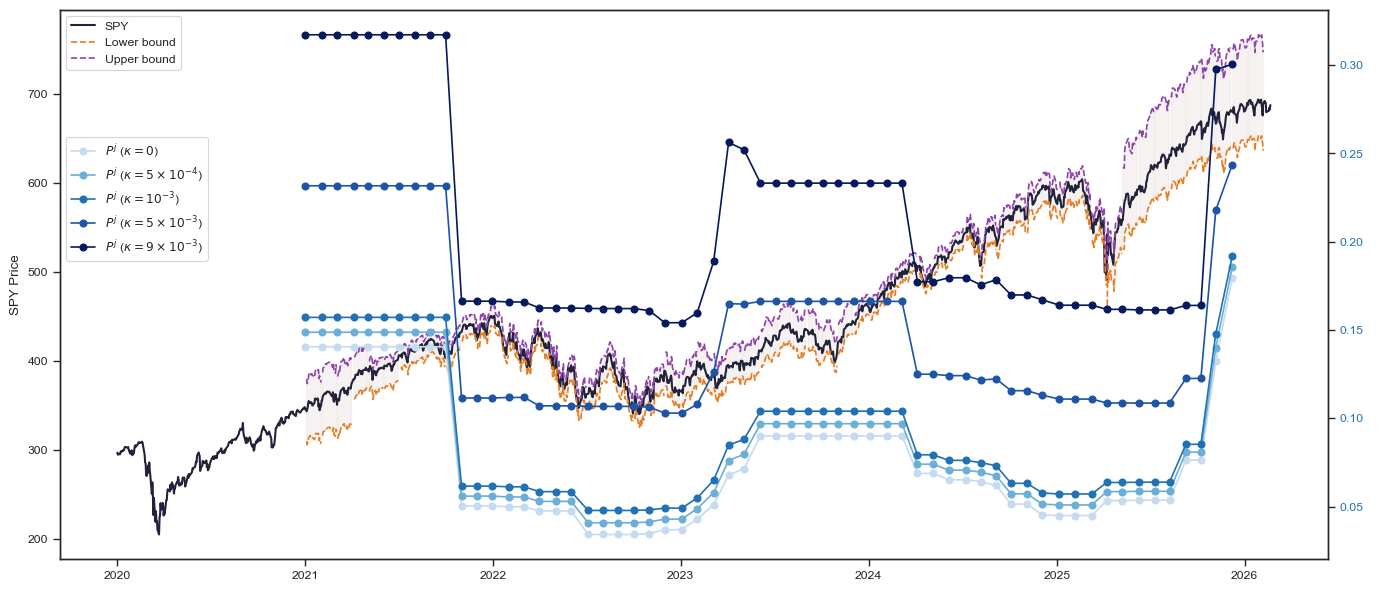

In [29]:
# -----------------------------
# 13. Overlay Plot: SPY, Support Bands, and Normalized Price (P^j)
# -----------------------------
# Overlay P^j for all four kappa values, each with a blue hue, using allm and synchronizing x-axis with period_starts.
pj_kappas = [r"$\kappa=0$", r"$\kappa=5\times10^{-4}$", r"$\kappa=10^{-3}$",r"$\kappa=5\times10^{-3}$", r"$\kappa=9\times10^{-3}$"]
# Blue palette (matches previous plots)
palette = {
    pj_kappas[0]: "#C6DBEF",  # lightest blue
    pj_kappas[1]: "#6BAED6",  # medium blue
    pj_kappas[2]: "#2171B5",  # dark blue
    pj_kappas[3]: "#1D54A6",  # deepest blue
    pj_kappas[4]: "#051A5C"   # darkest blue
}
pj_labels = [f"$P^j$ ({k})" for k in pj_kappas]

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot SPY price and support bands with harmonious, modern colors (but keep P^j blue)
# Lower bound: orange (#E67E22), Upper bound: violet (#8E44AD)
l1 = ax1.plot(close.index, close.values, color="#22223B", linewidth=1.5, label="SPY")  # deep blue-black
l2 = ax1.plot(close.index, lower_full.values, color="#E67E22", linewidth=1.2, linestyle="--", label="Lower bound")  # orange
l3 = ax1.plot(close.index, upper_full.values, color="#8E44AD", linewidth=1.2, linestyle="--", label="Upper bound")  # violet
ax1.fill_between(close.index, lower_full.values, upper_full.values, color="#C9ADA7", alpha=0.15)  # soft taupe

# Secondary axis for P^j for all kappas
ax2 = ax1.twinx()
pj_lines = []
for kappa_label, label in zip(pj_kappas, pj_labels):
    pj_mask = allm["kappa"] == kappa_label
    pj_df = allm.loc[pj_mask].copy()
    pj_df = pj_df.sort_values("i")  # Ensure correct order after filtering
    pj_curve = pj_df["Pj"].values
    # Use the period_starts corresponding to the sorted 'i' values for x-axis synchronization
    pj_x = [close.index[period_starts[i]] for i in pj_df["i"].values]
    line, = ax2.plot(pj_x, pj_curve, color=palette[kappa_label], marker="o", linestyle="-", label=label)
    pj_lines.append(line)

# Legends and labels
ax1.set_ylabel("SPY Price")
ax2.set_ylabel(" ", color="#2171B5")
ax2.tick_params(axis='y', labelcolor="#2171B5")

# Combine legends: calibration (ax1) first, then P^j (ax2) below
from matplotlib.legend import Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = zip(*[(line, line.get_label()) for line in pj_lines])
legend1 = ax1.legend(handles1, labels1, loc="upper left", frameon=True)
legend2 = ax1.legend(handles2, labels2, loc="upper left", bbox_to_anchor=(0, 0.78), frameon=True)
ax1.add_artist(legend1)  # Keep the first legend

#plt.title("SPY Price, Support Bands, and Normalized Price $P^j$ for All $\\kappa$")
plt.tight_layout()
plt.savefig("fig_spy_support_pj_overlay.pdf", bbox_inches="tight")
plt.savefig("fig_spy_support_pj_overlay.png", bbox_inches="tight")
plt.show()

In [20]:
# -----------------------------
# 14. Filtered Data: Tight Support, Summary Tables, and Cost Impact
# -----------------------------
# Filter allm for rows where support is tight (alpha_step >= 0.96, beta_step <= 1.04, Pj <= 1) for each kappa value.
cond_valid_0_bis = (allm['kappa'] == label_0) & (allm['alpha_step'] >=0.96)&(allm['beta_step'] <=1.04)&(allm['Pj'] <= 1)
cond_valid_0005_bis = (allm['kappa'] == label_0005) & (allm['alpha_step'] >=0.96)&(allm['beta_step'] <=1.04)&(allm['Pj'] <= 1)
cond_valid_001_bis = (allm['kappa'] == label_001) & (allm['alpha_step'] >=0.96)&(allm['beta_step'] <=1.04)&(allm['Pj'] <= 1)
cond_valid_01_bis = (allm['kappa'] == label_005) & (allm['alpha_step'] >=0.96)&(allm['beta_step'] <=1.04)&(allm['Pj'] <= 1)
allm_bis = allm[cond_valid_0_bis | cond_valid_0005_bis | cond_valid_001_bis | cond_valid_01_bis]

# Generate summary statistics for filtered data
stat_table_RSE_bis = allm_bis.groupby('kappa')['RSE'].describe()
stat_table_RSE_bis = stat_table_RSE_bis.reindex(kappa_order)
display(stat_table_RSE_bis.round(4))

stat_table_NP_bis= allm_bis.groupby('kappa')['Pj'].describe()
stat_table_NP_bis = stat_table_NP_bis.reindex(kappa_order)
display(stat_table_NP_bis.round(4))

df_impact_bis = dp.compute_I(allm_bis, pj_col="Pj", kappa_col="kappa", id_col="i")
stat_table_CI_bis = df_impact_bis.groupby('kappa')['I'].describe()
stat_table_CI_bis = stat_table_CI_bis.reindex(kappa_order_CI)
display(stat_table_CI_bis.round(4))

,count,mean,std,min,25%,50%,75%,max
kappa,,,,,,,,
$\kappa=0$,29.0,0.0374,0.0103,0.0217,0.0324,0.0374,0.0398,0.0681
$\kappa=5\times10^{-4}$,29.0,0.0426,0.0100,0.0283,0.0378,0.0426,0.0444,0.0729
$\kappa=10^{-3}$,29.0,0.0479,0.0097,0.0351,0.0435,0.0474,0.0500,0.0778
$\kappa=5\times10^{-3}$,29.0,0.0942,0.0097,0.0733,0.0891,0.0913,0.0954,0.1248
$\kappa=9\times10^{-3}$,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
kappa,,,,,,,,
$\kappa=0$,29.0,0.0464,0.0075,0.0342,0.0429,0.0475,0.0514,0.0619
$\kappa=5\times10^{-4}$,29.0,0.0522,0.0071,0.0408,0.0488,0.0529,0.0572,0.0674
$\kappa=10^{-3}$,29.0,0.0581,0.0066,0.0478,0.0548,0.0584,0.0631,0.0731
$\kappa=5\times10^{-3}$,29.0,0.1102,0.0050,0.1029,0.1070,0.1087,0.1115,0.1261
$\kappa=9\times10^{-3}$,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
kappa,,,,,,,,
$\kappa=5\times10^{-4}$,29.0,11.6156,1.0857,10.1490,10.7726,11.5883,12.0121,13.5802
$\kappa=10^{-3}$,29.0,11.7937,1.1603,10.2325,10.8995,11.7493,12.2109,13.8407
$\kappa=5\times10^{-3}$,29.0,12.7602,1.1980,11.0125,11.9040,12.8452,13.2051,15.0046
$\kappa=9\times10^{-3}$,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# -----------------------------
# 15. Export Filtered Summary Statistics Tables to LaTeX
# -----------------------------
# Export summary statistics tables (RSE, Cost Impact, Normalized Price) for filtered data to LaTeX files for publication.
stat_table_RSE_bis = stat_table_RSE_bis.reindex(kappa_order)
stat_table_NP_bis = stat_table_NP_bis.reindex(kappa_order)
stat_table_CI_bis = stat_table_CI_bis.reindex(kappa_order_CI)

cols_to_keep = ['count', 'mean', 'std','min', '50%','75%', 'max']

latex_df_RSE_bis = stat_table_RSE_bis[cols_to_keep].rename(columns={
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev', 'min': 'Min',
    '50%': 'Median', '75%': 'Q3', 'max': 'Max'
})
latex_df_CI_bis = stat_table_CI_bis[cols_to_keep].rename(columns={
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev', 'min': 'Min',
    '50%': 'Median', '75%': 'Q3', 'max': 'Max'
})
latex_df_NP_bis = stat_table_NP_bis[cols_to_keep].rename(columns={
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev', 'min': 'Min',
    '50%': 'Median', '75%': 'Q3', 'max': 'Max'
})

# Generate the LaTeX code and write to files
latex_code_RSE_bis = latex_df_RSE_bis.to_latex(
    float_format="%.4f",
    caption=r"Summary statistics of the super-hedging relative difference on filtered data.",
    label="tab:relative_standard_error_bis",
    escape=False
)

latex_code_CI_bis = latex_df_CI_bis.to_latex(
    float_format="%.4f",
    caption=r"Summary statistics of the Cost Impact on filtered data.",
    label="tab:cost_impact_bis",
    escape=False
)

latex_code_NP_bis = latex_df_NP_bis.to_latex(
    float_format="%.4f",
    caption=r"Summary statistics of the normalized price on filtered data.",
    label="tab:normalized_super_hedging_price_bis",
    escape=False
)

with open("table_relative_superhedging_error_bis.tex", "w") as f:
    f.write(latex_code_RSE_bis)

with open("table_cost_impact_bis.tex", "w") as f:
    f.write(latex_code_CI_bis)

with open("table_normalized_price_bis.tex", "w") as f:
    f.write(latex_code_NP_bis)

In [22]:
# -----------------------------
# 16. Cost Impact Grid Study: Load, Clean, and Compute I(kappa)
# -----------------------------
# Load grid test results, clean data, and compute cost impact for a range of kappa values.
df_CI = pd.read_csv("results_kappa_grid_test.csv")

# Convert relevant columns to numeric (handles [value] format)
for c in ["VT", "ST", "payoff", "V0", "S0", "kappa", "alpha_step", "beta_step"]:
    df_CI[c] = df_CI[c].map(dp.to_float)

df_CI["P"] = df_CI["V0"] / df_CI["S0"].where(df_CI["S0"].abs() > 1e-12)
# Extract scalar P(0) for reference
P0 = df_CI.loc[df_CI["kappa"] == 0.0, "P"].iloc[0]

# Compute I(kappa) for kappa > 0 and kappa < 0.01
df_nonzero = df_CI[(df_CI["kappa"] > 0.0) & (df_CI["kappa"] < 0.01)].copy()
df_nonzero["I"] = (df_nonzero["P"] - P0)

df_nonzero

,i,kappa,V0,VT,ST,S0,K_payoff,payoff,alpha_step,beta_step,P,I
1,0,0.000001,34.577246,33.414927,379.873596,384.024536,[384.02453613],7.387982,0.956517,1.054954,0.090039,0.000014
2,0,0.000001,34.577761,33.415450,379.873596,384.024536,[384.02453613],7.387999,0.956517,1.054954,0.090040,0.000015
3,0,0.000001,34.578326,33.416024,379.873596,384.024536,[384.02453613],7.388017,0.956517,1.054954,0.090042,0.000016
4,0,0.000001,34.578948,33.416655,379.873596,384.024536,[384.02453613],7.388038,0.956517,1.054954,0.090044,0.000018
5,0,0.000001,34.579631,33.417347,379.873596,384.024536,[384.02453613],7.388060,0.956517,1.054954,0.090045,0.000020
...,...,...,...,...,...,...,...,...,...,...,...,...
94,0,0.006251,71.992377,71.020651,379.873596,384.024536,[384.02453613],8.449798,0.956517,1.054954,0.187468,0.097443
95,0,0.006866,76.110090,75.126306,379.873596,384.024536,[384.02453613],8.554447,0.956517,1.054954,0.198191,0.108165
96,0,0.007543,79.808107,78.725629,379.873596,384.024536,[384.02453613],8.669409,0.956517,1.054954,0.207820,0.117795
97,0,0.008286,84.685940,83.567346,379.873596,384.024536,[384.02453613],8.795699,0.956517,1.054954,0.220522,0.130497


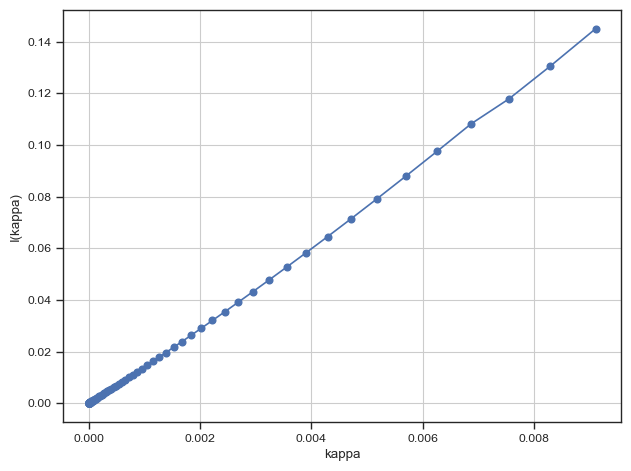

In [23]:
# -----------------------------
# 17. Plot: Cost Impact vs Kappa (Grid Study)
# -----------------------------
# Plot cost impact I(kappa) as a function of kappa from the grid study.
plt.plot(df_nonzero["kappa"], df_nonzero["I"], marker='o')
plt.xlabel("kappa")
plt.ylabel("I(kappa)")
plt.grid(True)
plt.tight_layout()
plt.savefig("fig_CIvsk.pdf", bbox_inches="tight")
plt.show()

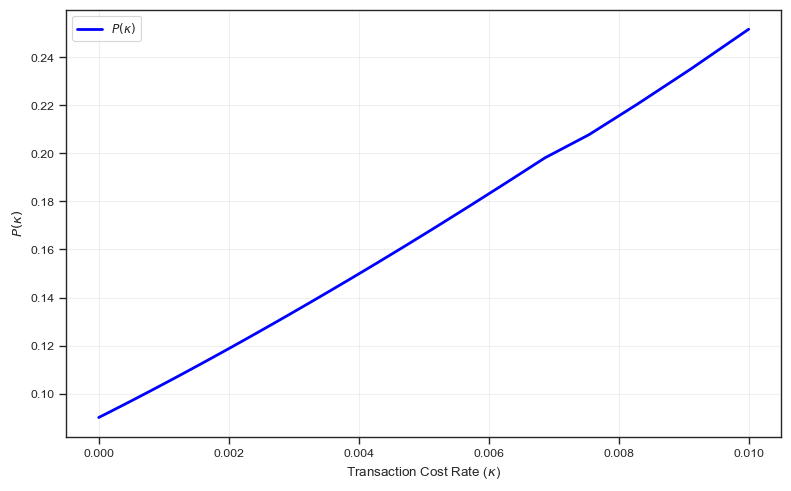

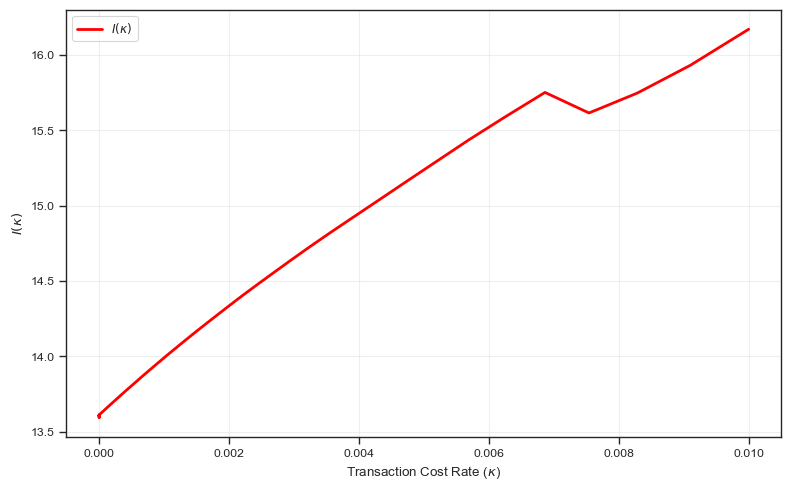

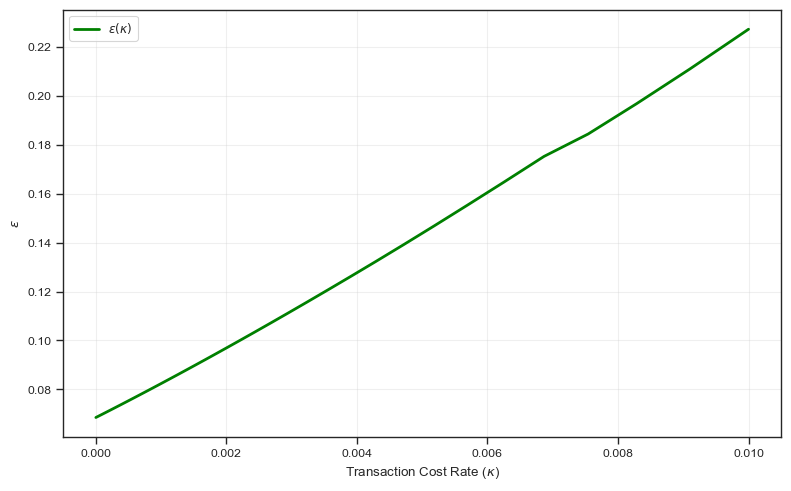

In [24]:
# -----------------------------
# 18. Continuous Cost Impact and Super-Hedging Difference Analysis
# -----------------------------
# Load, clean, and analyze continuous grid data for cost impact and super-hedging difference.
df = pd.read_csv("results_kappa_grid_test.csv")

# Clean columns (handles [value] format in CSV)
cols_to_clean = ['V0', 'VT', 'ST', 'S0', 'K_payoff', 'payoff']
for col in cols_to_clean:
    df[col] = df[col].astype(str).str.replace(r'[\[\]]', '', regex=True).astype(float)

# Normalized Price P(kappa)
df['P_kappa'] = df['V0'] / df['S0']

# Reference frictionless price P(0)
p_0 = df.loc[df['kappa'] == 0, 'P_kappa'].values[0]

# Cost Impact I(kappa) = (P(kappa) - P(0)) / kappa (avoid division by zero)
df['I_kappa'] = np.where(df['kappa'] > 0, (df['P_kappa'] - p_0) / df['kappa'], np.nan)

# Relative super-hedging difference epsilon = (VT - payoff) / ST
df['epsilon'] = (df['VT'] - df['payoff']) / df['ST']

# --- Plotting and Saving ---
# Figure 1: Normalized Price P(kappa)
plt.figure(figsize=(8, 5))
plt.plot(df['kappa'], df['P_kappa'], color='blue', linewidth=2, label=r'$P(\kappa)$')
#plt.title(r'Normalized Super-hedging Price $P(\kappa) = V_0(\kappa)/S_0$')
plt.xlabel(r'Transaction Cost Rate ($\kappa$)')
plt.ylabel(r'$P(\kappa)$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('fig_p_kappa_continuous.pdf')

# Figure 2: Cost Impact I(kappa)
plt.figure(figsize=(8, 5))
plt.plot(df['kappa'], df['I_kappa'], color='red', linewidth=2, label=r'$I(\kappa)$')
#plt.title(r'Cost Impact $I(\kappa) = (P(\kappa) - P(0))/\kappa$')
plt.xlabel(r'Transaction Cost Rate ($\kappa$)')
plt.ylabel(r'$I(\kappa)$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('fig_i_kappa_continuous.pdf')

# Figure 3: Relative Super-hedging Difference epsilon(kappa)
plt.figure(figsize=(8, 5))
plt.plot(df['kappa'], df['epsilon'], color='green', linewidth=2, label=r'$\epsilon(\kappa)$')
#plt.title(r'Relative Super-hedging Difference $\epsilon(\kappa)$')
plt.xlabel(r'Transaction Cost Rate ($\kappa$)')
plt.ylabel(r'$\epsilon$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('fig_epsilon_kappa_continuous.pdf')

Fit Result: P(kappa) = 204.76*kappa^2 + 14.15*kappa + 0.0899


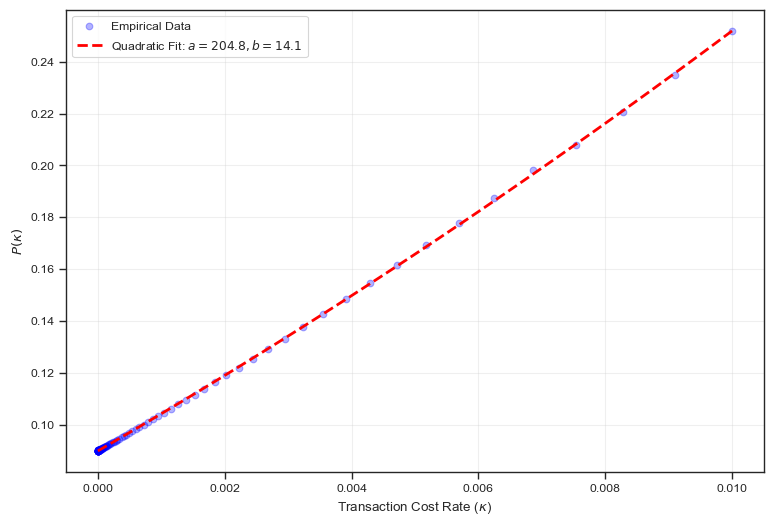

In [25]:
# -----------------------------
# 19. Quadratic Approximation of Normalized Price $P(\kappa)$
# -----------------------------
# Fit and plot a quadratic model for normalized price as a function of kappa.
df = pd.read_csv("results_kappa_grid_test.csv")
for col in ['V0', 'S0']:
    df[col] = df[col].astype(str).str.replace(r'[\[\]]', '', regex=True).astype(float)

# Normalize and fit quadratic model
df['P_kappa'] = df['V0'] / df['S0']
kappa = df['kappa'].values
P = df['P_kappa'].values

# Fit P(kappa) = a*kappa^2 + b*kappa + c
coeffs = np.polyfit(kappa, P, 2)
a, b, c = coeffs

# Plot the fit
kappa_range = np.linspace(kappa.min(), kappa.max(), 100)
P_fit = a * kappa_range**2 + b * kappa_range + c

plt.figure(figsize=(9, 6))
plt.scatter(kappa, P, color='blue', alpha=0.3, label='Empirical Data')
plt.plot(kappa_range, P_fit, color='red', linestyle='--', linewidth=2, label=fr'Quadratic Fit: $a={a:.1f}, b={b:.1f}$')
#plt.title(r'Quadratic Approximation of Normalized Price $P(\kappa)$')
plt.xlabel(r'Transaction Cost Rate ($\kappa$)')
plt.ylabel(r'$P(\kappa)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('fig_quadratic_fit_p.pdf')

print(f"Fit Result: P(kappa) = {a:.2f}*kappa^2 + {b:.2f}*kappa + {c:.4f}")

Fit Coefficients: A=-15018.603410567954, B=397.4409890267613, C=13.607691917563354
R-squared: 0.9981177515634242


<>:32: SyntaxWarning: invalid escape sequence '\k'
<>:32: SyntaxWarning: invalid escape sequence '\k'
/var/folders/4k/trxq2k6x01733zhpvkj8dppr0000gq/T/ipykernel_1798/1308776747.py:32: SyntaxWarning: invalid escape sequence '\k'
  plt.scatter(kappa, I_emp, color='black', alpha=0.3, label='Empirical $I(\kappa)$')


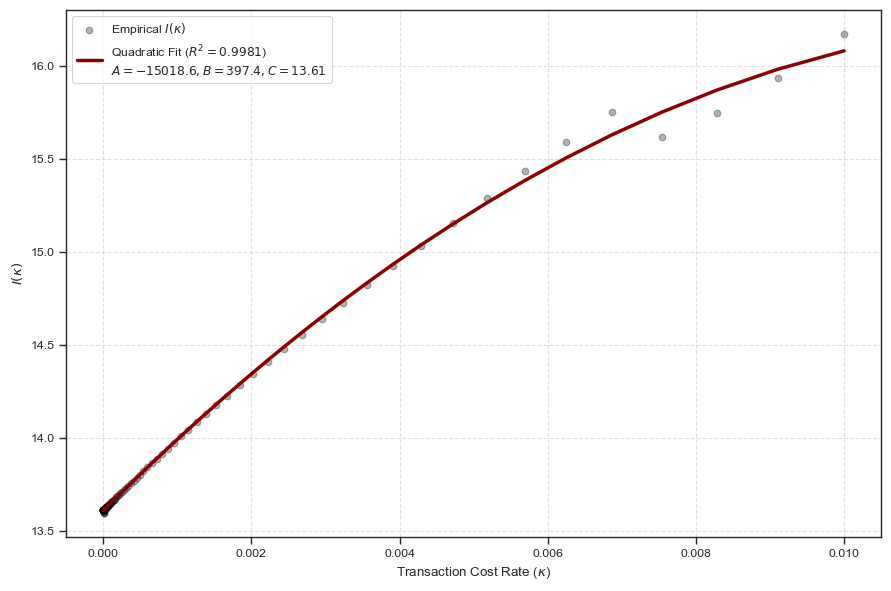

In [26]:
# -----------------------------
# 20. Quadratic Fit: Cost Impact $I(\kappa)$ vs $\kappa$
# -----------------------------
# This cell fits a quadratic model to the empirical cost impact I(kappa) as a function of kappa,
# and visualizes the fit alongside the empirical data points.

# Step 1: Load the grid study results for kappa and clean columns
df = pd.read_csv("results_kappa_grid_test.csv")

# Step 2: Clean columns (remove brackets and convert to float)
cols_to_clean = ['V0', 'S0']
for col in cols_to_clean:
    df[col] = df[col].astype(str).str.replace(r'[\[\]]', '', regex=True).astype(float)

# Step 3: Compute normalized price and reference value for kappa=0
df['P_kappa'] = df['V0'] / df['S0']
p_0 = df.loc[df['kappa'] == 0, 'P_kappa'].values[0]

# Step 4: Compute empirical cost impact I(kappa) for kappa > 0
df_i = df[df['kappa'] > 0].copy()
kappa = df_i['kappa'].values
I_emp = (df_i['P_kappa'] - p_0) / df_i['kappa']  # Avoid division by zero

# Step 5: Fit a quadratic model: I(kappa) = A*kappa^2 + B*kappa + C
coeffs = np.polyfit(kappa, I_emp, 2)
A, B, C = coeffs
I_fit = np.polyval(coeffs, kappa)
r2 = r2_score(I_emp, I_fit)  # Goodness of fit

# Step 6: Plot empirical I(kappa) and quadratic fit
plt.figure(figsize=(9, 6))
plt.scatter(kappa, I_emp, color='black', alpha=0.3, label='Empirical $I(\kappa)$')
plt.plot(kappa, I_fit, color='darkred', linewidth=2.5, 
         label=f'Quadratic Fit ($R^2={r2:.4f}$)\n$A={A:.1f}, B={B:.1f}, C={C:.2f}$')
plt.xlabel(r'Transaction Cost Rate ($\kappa$)')
plt.ylabel(r'$I(\kappa)$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save the plot to file
plt.savefig('fig_i_kappa_quadratic_fit.pdf')

# Print fit coefficients and R-squared for reporting
print(f"Fit Coefficients: A={A}, B={B}, C={C}")
print(f"R-squared: {r2}")